# House Price Prediction using Linear Regression

## Objective

The objective of this project is to build a Linear Regression model to predict house sale prices based on various property features.

In this project, we will explore the dataset, preprocess the data, select relevant features, train a Linear Regression model, evaluate its performance, and analyze the results.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the DataSet

In [2]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv")


In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Data Overview

Before performing exploratory data analysis and building the Linear Regression model, we first examine the overall structure of the dataset.

This section helps us understand the dataset dimensions, sample records, column data types, and basic statistical information.

In [4]:
train.shape

(1460, 81)

### Observation

- The training dataset contains 1,460 rows and 81 columns.
- Each row represents one house/property.
- The columns contain different characteristics of the houses along with the target variable SalePrice.

In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Observation

- The dataset contains a combination of numerical and categorical features describing different characteristics of houses.
- Each row represents an individual property.
- SalePrice is the target variable that we will later predict using Linear Regression.

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Observation

- The dataset contains numerical as well as categorical features.
- Numerical columns are represented mainly by int64 and float64 data types.
- Categorical columns are represented by the object data type.
- Some columns contain fewer than 1,460 non-null values, indicating the presence of missing values.

In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Observation

- The numerical features vary considerably in their ranges and distributions.
- SalePrice shows substantial variation among properties, indicating differences in house values.
- Some numerical features contain zero values, which may represent the absence of certain house characteristics.
- The summary statistics provide an initial understanding of the center, spread, and range of numerical features.

## 2. Missing Value Analysis

Before preparing the data for the Linear Regression model, we need to identify the features that contain missing values. This will help us decide how to handle them during the preprocessing stage.

In [8]:
missing_values = train.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

### Observation

- Several features in the dataset contain missing values.
- PoolQC, MiscFeature, Alley and Fence have a large number of missing values.
- Some features such as LotFrontage and GarageYrBlt also have noticeable missing values.
- A missing value does not always mean that the data was not recorded. For some features, it may indicate that the house does not have that particular facility.
- We will decide how to handle these missing values later during the preprocessing stage.

## 3. Target Analysis

Before building the Linear Regression model, we need to understand the distribution of our target variable, SalePrice. This helps us see the typical range of house prices, the spread of the values, and whether the distribution is symmetric or skewed.

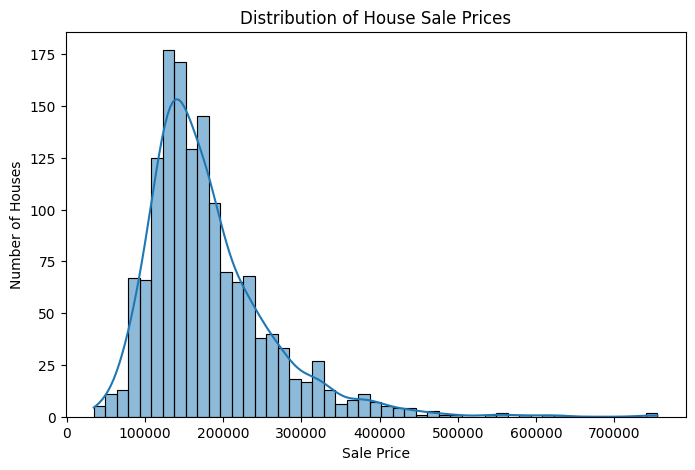

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=train,
    x="SalePrice",
    kde=True,
    ax=ax,
)

ax.set_title("Distribution of House Sale Prices")
ax.set_xlabel("Sale Price")
ax.set_ylabel("Number of Houses")

plt.show()

### Observation

- Most houses are concentrated in the lower to middle price range.
- The number of houses gradually decreases as the sale price increases.
- A small number of houses have much higher sale prices compared to most houses in the dataset.
- The distribution has a longer tail towards the higher prices, which shows that SalePrice is right-skewed.
- The target variable is not normally distributed and may need further consideration before building the Linear Regression model.

## 4. Numerical Feature Analysis

In this section, we will analyze the relationship between the numerical features and SalePrice using correlation. This will help us identify which numerical features are more strongly related to house prices and may be useful for our Linear Regression model.

In [10]:
numerical_features = train.select_dtypes(include=["int64", "float64"])
numerical_features.shape


(1460, 38)

### Observation

- The dataset contains a number of numerical features describing different characteristics of the houses.
- These features include values such as area, number of rooms, year built, quality ratings and SalePrice.
- We will use these numerical features to calculate their correlation with SalePrice.

In [11]:
saleprice_corr = numerical_features.corr()["SalePrice"].sort_values(ascending=False)
saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Observation

- OverallQual has one of the strongest positive correlations with SalePrice, showing that houses with better overall quality generally have higher sale prices.
- GrLivArea also has a strong positive correlation, suggesting that houses with larger above-ground living areas generally sell for higher prices.
- GarageCars, GarageArea, TotalBsmtSF and 1stFlrSF also show relatively strong positive relationships with SalePrice.
- Some numerical features have weak correlations with SalePrice, which means they do not show a strong direct linear relationship with house prices.
- These correlations give us an initial idea of potentially useful numerical features, but we will not select or remove features based only on correlation.

## 5. Correlation Heatmap

In the previous section, we identified the numerical features that have a stronger correlation with SalePrice. Now, we will use a heatmap to compare these important features with SalePrice and also check how strongly they are related to each other.

This helps us identify possible multicollinearity, where two or more input features provide very similar information.

In [12]:
top_features = saleprice_corr.head(11).index
top_features

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd'],
      dtype='object')

### Observation

- The selected features have some of the strongest positive correlations with SalePrice among the numerical columns.
- Features related to overall quality, living area, garage size, basement area and construction year appear among the more strongly related features.
- We will now compare these features with each other to check whether some of them contain similar information.

In [13]:
corr_matrix = train[top_features].corr()
corr_matrix

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
SalePrice,1.000000,0.790982,0.708624,0.640409,0.623431,0.613581,0.605852,0.560664,0.533723,0.522897,0.507101
OverallQual,0.790982,1.000000,0.593007,0.600671,0.562022,0.537808,0.476224,0.550600,0.427452,0.572323,0.550684
GrLivArea,0.708624,0.593007,1.000000,0.467247,0.468997,0.454868,0.566024,0.630012,0.825489,0.199010,0.287389
GarageCars,0.640409,0.600671,0.467247,1.000000,0.882475,0.434585,0.439317,0.469672,0.362289,0.537850,0.420622
GarageArea,0.623431,0.562022,0.468997,0.882475,1.000000,0.486665,0.489782,0.405656,0.337822,0.478954,0.371600
TotalBsmtSF,0.613581,0.537808,0.454868,0.434585,0.486665,1.000000,0.819530,0.323722,0.285573,0.391452,0.291066
1stFlrSF,0.605852,0.476224,0.566024,0.439317,0.489782,0.819530,1.000000,0.380637,0.409516,0.281986,0.240379
FullBath,0.560664,0.550600,0.630012,0.469672,0.405656,0.323722,0.380637,1.000000,0.554784,0.468271,0.439046
TotRmsAbvGrd,0.533723,0.427452,0.825489,0.362289,0.337822,0.285573,0.409516,0.554784,1.000000,0.095589,0.191740
YearBuilt,0.522897,0.572323,0.199010,0.537850,0.478954,0.391452,0.281986,0.468271,0.095589,1.000000,0.592855


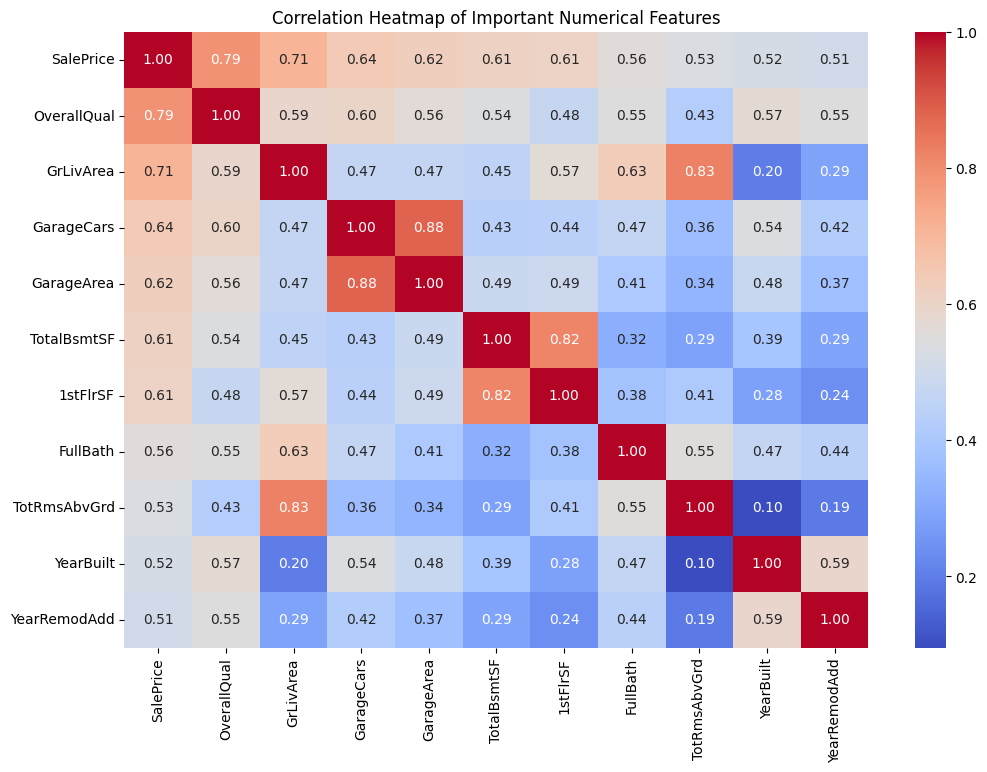

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax
)

ax.set_title("Correlation Heatmap of Important Numerical Features")

plt.show()

### Observation

- OverallQual and GrLivArea show strong positive relationships with SalePrice.
- GarageCars and GarageArea are strongly related to each other, which is expected because garages with more car capacity generally have a larger area.
- TotalBsmtSF and 1stFlrSF also show a strong relationship, as the basement and first-floor sizes are often related to the overall size of the house.
- GrLivArea and TotRmsAbvGrd are also related because houses with larger living areas generally contain more rooms.
- Some features may provide overlapping information, so we need to consider multicollinearity before making the final feature selection.

## 6. Individual Relationships

After identifying the numerical features that are highly correlated with SalePrice, we will now visualize some of these relationships individually. This helps us understand how house prices change with important numerical features and also allows us to notice unusual values or patterns that may not be clear from correlation values alone.

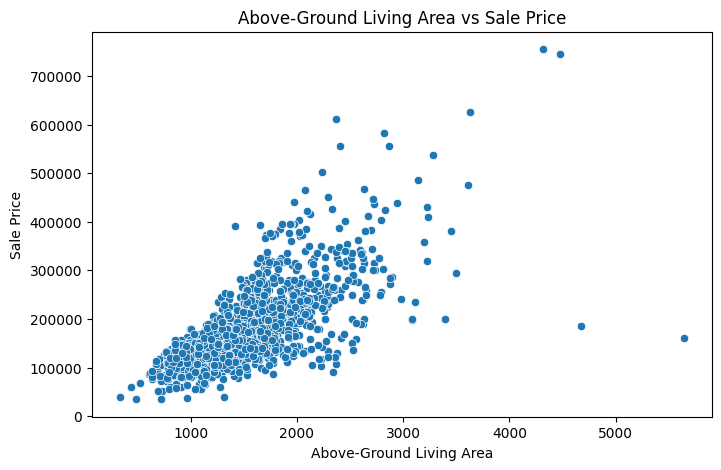

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    ax=ax
)

ax.set_title("Above-Ground Living Area vs Sale Price")
ax.set_xlabel("Above-Ground Living Area")
ax.set_ylabel("Sale Price")

plt.show()

### Observation

- SalePrice generally increases as the above-ground living area increases.
- Most houses are concentrated in the lower and middle ranges of living area and sale price.
- The relationship shows a clear positive trend, which supports the strong positive correlation found earlier.
- A few houses have very large living areas but relatively low sale prices compared to the general pattern.
- These unusual observations may be possible outliers, which we will examine more carefully in the outlier analysis section.

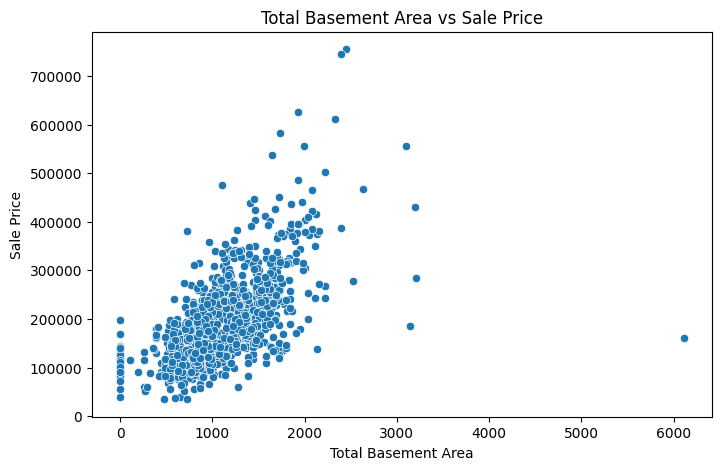

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="TotalBsmtSF",
    y="SalePrice",
    ax=ax
)

ax.set_title("Total Basement Area vs Sale Price")
ax.set_xlabel("Total Basement Area")
ax.set_ylabel("Sale Price")

plt.show()

### Observation

- Houses with larger basement areas generally tend to have higher sale prices.
- Most houses are concentrated within the lower and middle ranges of basement area.
- The relationship is positive, although the points are more spread out compared to a perfectly linear relationship.
- Some houses have no basement area, while a few houses have unusually large basement areas.
- These unusual values should be examined before deciding whether they need any treatment.

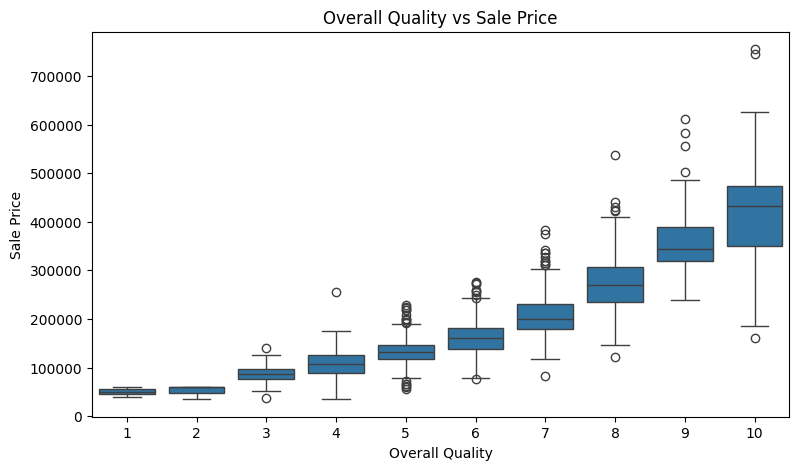

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=train,
    x="OverallQual",
    y="SalePrice",
    ax=ax
)

ax.set_title("Overall Quality vs Sale Price")
ax.set_xlabel("Overall Quality")
ax.set_ylabel("Sale Price")

plt.show()

### Observation

- Houses with higher overall quality ratings generally have higher sale prices.
- The median sale price increases noticeably as the quality rating increases.
- Houses with lower quality ratings are mostly concentrated in lower price ranges, while high-quality houses show much higher sale prices.
- The spread of sale prices becomes larger for some of the higher quality ratings.
- This clear pattern supports the strong positive correlation between OverallQual and SalePrice.

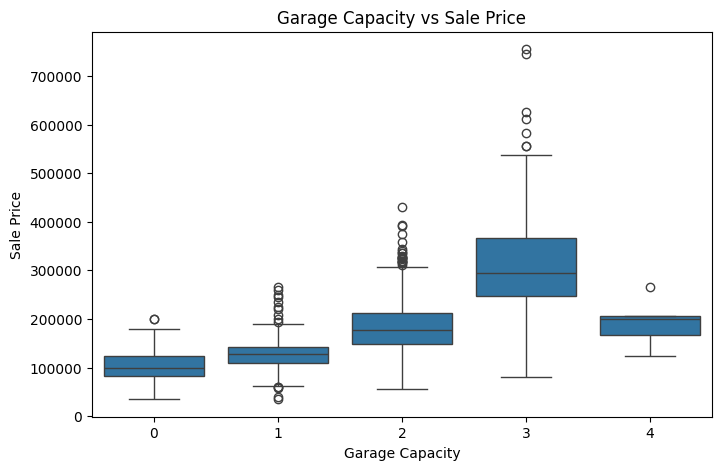

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="GarageCars",
    y="SalePrice",
    ax=ax
)

ax.set_title("Garage Capacity vs Sale Price")
ax.set_xlabel("Garage Capacity")
ax.set_ylabel("Sale Price")

plt.show()

### Observation

- Houses with larger garage capacity generally have higher sale prices.
- Houses with no garage or space for only one car tend to have lower sale prices compared to houses with two or more garage spaces.
- The median sale price generally increases as garage capacity increases.
- Some groups contain unusual high or low sale prices, showing that garage capacity alone does not determine the final house price.

## 7. Categorical Feature Analysis

So far, we have mainly analyzed numerical features using correlation and different visualizations. However, the dataset also contains categorical features that may have an important relationship with SalePrice.

In this section, we will analyze some important categorical features and compare how house prices vary across their different categories.

In [19]:
categorical_features = train.select_dtypes(include=["object"]).columns

categorical_features

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

### Observation

- The dataset contains several categorical features describing the location, type, quality and other characteristics of the houses.
- These features were not included in our numerical correlation analysis because they contain category labels instead of continuous numerical values.
- We need to analyze them separately to understand whether different categories are associated with different house prices.

In [20]:
neighborhood_price = (
    train.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

neighborhood_price

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

### Observation

- The average sale price varies noticeably across different neighborhoods.
- Some neighborhoods have much higher average house prices than others.
- This suggests that the location of a house has an important relationship with its sale price.
- Neighborhood may therefore be a useful categorical feature when building the prediction model.

### 7.1 Neighbourhood vs SalePrice

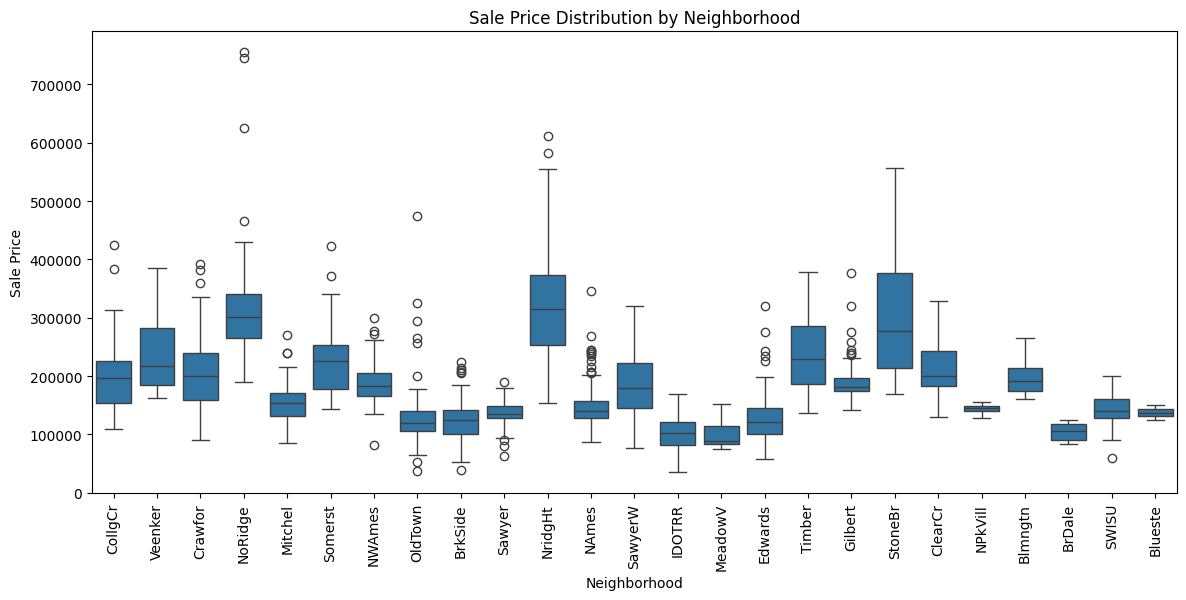

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=train,
    x="Neighborhood",
    y="SalePrice",
    ax=ax
)

ax.set_title("Sale Price Distribution by Neighborhood")
ax.set_xlabel("Neighborhood")
ax.set_ylabel("Sale Price")

ax.tick_params(axis="x", rotation=90)

plt.show()

#### Observation

- Sale prices differ considerably across neighborhoods.
- Some neighborhoods generally contain higher-priced houses, while others are concentrated in lower price ranges.
- The spread of house prices also differs between neighborhoods, showing that some locations have a wider range of property values.
- A few neighborhoods contain unusually expensive houses compared to most properties in the same area.
- The clear differences between neighborhoods suggest that Neighborhood could be useful for predicting SalePrice.

### 7.2 KitchenQual vs SalePrice

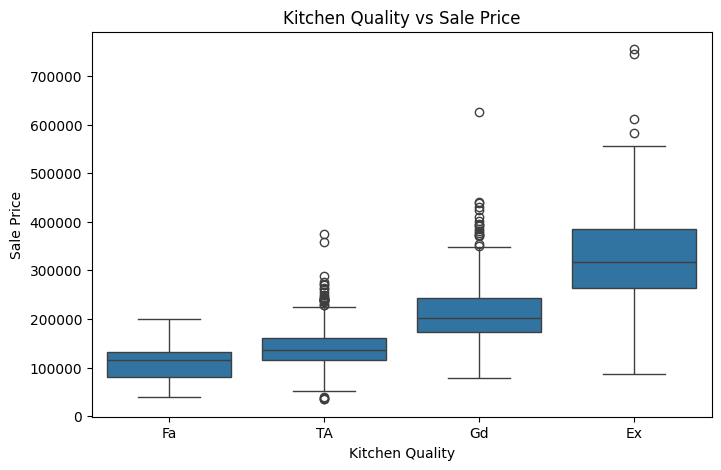

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="KitchenQual",
    y="SalePrice",
    order=["Fa", "TA", "Gd", "Ex"],
    ax=ax
)

ax.set_title("Kitchen Quality vs Sale Price")
ax.set_xlabel("Kitchen Quality")
ax.set_ylabel("Sale Price")

plt.show()

#### Observation

- Houses with better kitchen quality generally have higher sale prices.
- Houses with excellent kitchens have noticeably higher median sale prices compared to houses with fair or typical kitchens.
- The sale price generally increases as kitchen quality improves.
- This shows that KitchenQual has a meaningful relationship with SalePrice and may be useful for the prediction model.

### 7.3 ExterQual vs SalePrice

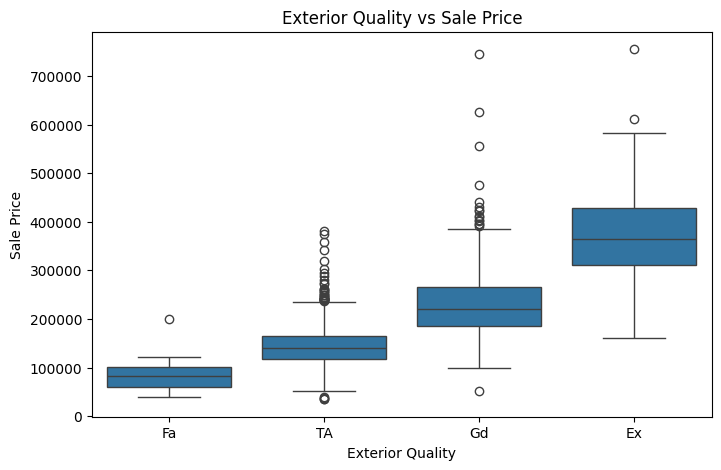

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="ExterQual",
    y="SalePrice",
    order=["Fa", "TA", "Gd", "Ex"],
    ax=ax
)

ax.set_title("Exterior Quality vs Sale Price")
ax.set_xlabel("Exterior Quality")
ax.set_ylabel("Sale Price")

plt.show()

#### Observation

- Houses with better exterior quality generally have higher sale prices.
- The median sale price increases as the exterior quality improves from fair to excellent.
- Houses with excellent exterior quality are concentrated in much higher price ranges compared to houses with average or fair exterior quality.
- This suggests that ExterQual may provide useful information for predicting house prices.

### 7.4 Central Air vs SalePrice

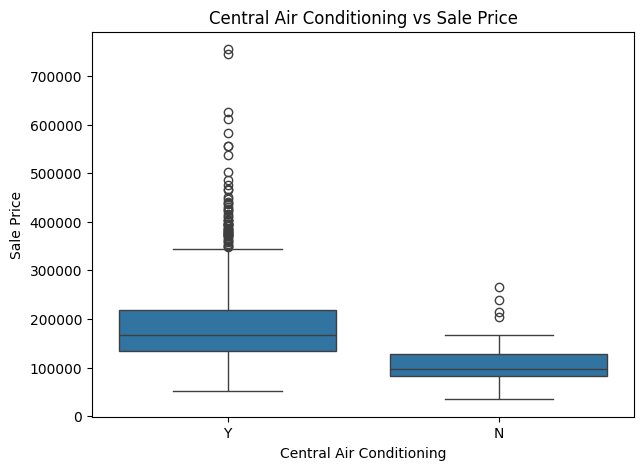

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=train,
    x="CentralAir",
    y="SalePrice",
    ax=ax
)

ax.set_title("Central Air Conditioning vs Sale Price")
ax.set_xlabel("Central Air Conditioning")
ax.set_ylabel("Sale Price")

plt.show()

#### Observation

- Houses with central air conditioning generally have higher sale prices than houses without it.
- The median sale price is noticeably higher for houses that have central air conditioning.
- However, the difference in price may also be related to other characteristics of these houses, so CentralAir should not be considered the only reason for the price difference.

## 8. Outlier Analysis

In the previous analysis, we noticed some unusual observations in important numerical features. In this section, we will identify potential outliers using box plots and the IQR method.

Outliers are not always incorrect data, so we will first identify and examine them before deciding whether they should be removed.

### 8.1 Visualize Outliers in SalePrice

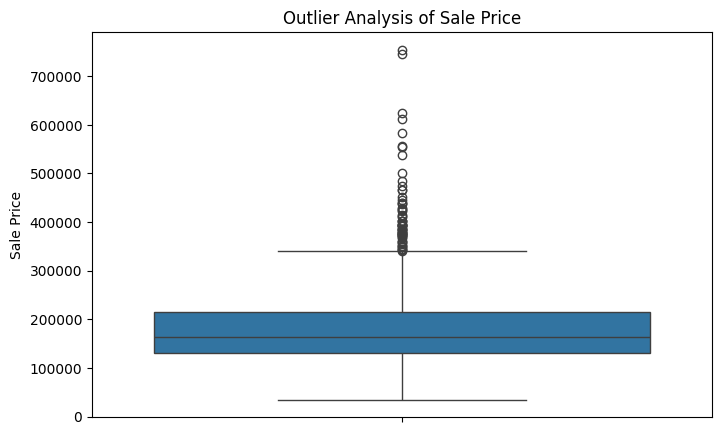

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=train,
    y="SalePrice",
    ax=ax
)

ax.set_title("Outlier Analysis of Sale Price")
ax.set_ylabel("Sale Price")

plt.show()

#### Observation

- Most house prices are concentrated within the main range shown by the box and whiskers.
- Several houses appear above the upper whisker, indicating unusually high sale prices compared to most houses in the dataset.
- These values are potential outliers, but they may represent genuine expensive houses rather than incorrect data.
- We should not remove these observations only because they appear outside the whiskers.

### 8.2 Calculate IQR for SalePrice

In [26]:
Q1 = train["SalePrice"].quantile(0.25)
Q3 = train["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 129975.0
Q3: 214000.0
IQR: 84025.0
Lower Bound: 3937.5
Upper Bound: 340037.5


### Indenity SalePrice Outliers

In [27]:
saleprice_outliers = train[
    (train["SalePrice"] < lower_bound) |
    (train["SalePrice"] > upper_bound)
]

saleprice_outliers[["Id", "SalePrice"]].head()

,Id,SalePrice
11,12,345000
53,54,385000
58,59,438780
112,113,383970
151,152,372402


In [28]:
saleprice_outliers.shape[0]

61

#### Observation

- The IQR method identifies a number of houses with SalePrice values outside the calculated lower and upper boundaries.
- Most of the unusual values are on the higher-price side because the SalePrice distribution is right-skewed.
- These houses may simply be genuinely expensive properties, so being identified as an outlier does not automatically mean that the observation should be removed.

### 8.3 Analyze GrLivArea for Unusual Observations

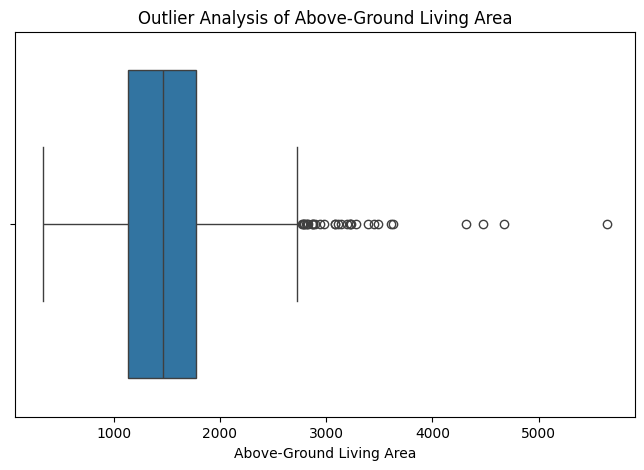

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="GrLivArea",
    ax=ax
)

ax.set_title("Outlier Analysis of Above-Ground Living Area")
ax.set_xlabel("Above-Ground Living Area")

plt.show()

#### Observation

- Most houses have living areas within a relatively concentrated range.
- A small number of houses have much larger living areas than most properties in the dataset.
- These observations appear as potential outliers in the box plot.
- Large living areas are not necessarily incorrect, so their relationship with SalePrice should also be examined before making any removal decision.

### 8.4 Why a Scatter Plot is Escpecially Important Here

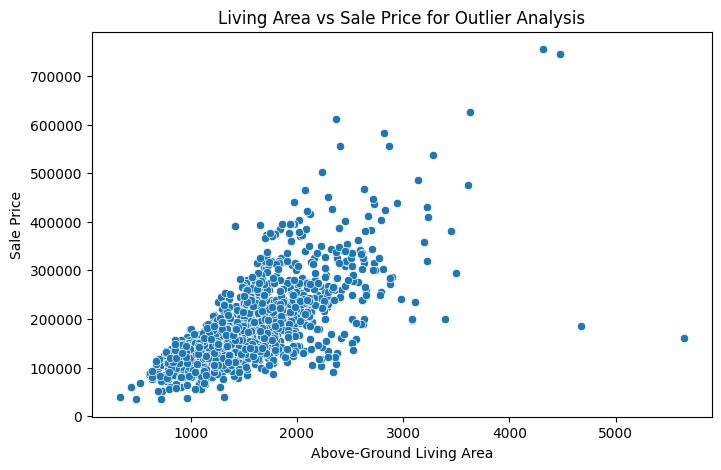

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    ax=ax
)

ax.set_title("Living Area vs Sale Price for Outlier Analysis")
ax.set_xlabel("Above-Ground Living Area")
ax.set_ylabel("Sale Price")

plt.show()

#### Observation

- Most houses follow a positive relationship where larger living areas are associated with higher sale prices.
- A few houses have very large living areas compared to the majority of the dataset.
- Some of these large houses do not follow the general relationship between living area and sale price.
- These observations may have a stronger influence on the Linear Regression line and should be examined carefully before model training.

## ## What Did We Learn from Our EDA?

- The dataset contains both numerical and categorical features, and several columns have missing values that will need to be handled before model training.

- SalePrice is right-skewed, with most houses concentrated in the lower to middle price range and a smaller number of houses having very high sale prices.

- OverallQual and GrLivArea showed some of the strongest positive relationships with SalePrice.

- GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, YearBuilt and YearRemodAdd also showed noticeable positive relationships with SalePrice.

- Some numerical features are strongly related to each other. For example, GarageCars and GarageArea provide similar information about garage size, while GrLivArea and TotRmsAbvGrd both provide information related to the overall size of the house.

- Categorical features also showed meaningful differences in house prices. Neighborhood, KitchenQual, ExterQual and CentralAir showed clear variations in SalePrice across their categories.

- Some unusually high values were found in SalePrice and features such as GrLivArea. These values may represent genuine expensive or large houses, so they should not be removed only because they appear as outliers.

- Based on these findings, we can now select a smaller set of useful numerical and categorical features for our first Linear Regression model.

## 9. Feature Selection

After analyzing numerical correlations, individual relationships, categorical features and possible outliers, we can now select a set of useful features for our Linear Regression model.

The selected features should have a meaningful relationship with SalePrice while also representing different characteristics of a house such as quality, size, age, location and facilities.

### 9.1 Selecting Numerical Features

In [31]:
numerical_selected = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "YearRemodAdd"
]

numerical_selected

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'TotalBsmtSF',
 'FullBath',
 'YearBuilt',
 'YearRemodAdd']

#### Observation

- OverallQual is selected because it showed one of the strongest relationships with SalePrice.
- GrLivArea represents the usable above-ground living space and showed a clear positive relationship with house prices.
- GarageCars represents garage capacity and was selected instead of using both GarageCars and GarageArea, as these two features contain similar information.
- TotalBsmtSF represents the total basement area and provides information about the size of the house.
- FullBath represents an important facility available in the house.
- YearBuilt and YearRemodAdd provide information about the age of the property and whether it has been remodeled.

### 9.2 Selecting Categorical Features

In [32]:
categorical_selected = [
    "Neighborhood",
    "KitchenQual",
    "ExterQual",
    "CentralAir"
]

categorical_selected

['Neighborhood', 'KitchenQual', 'ExterQual', 'CentralAir']

#### Observation

- Neighborhood is selected because house prices varied considerably across different locations.
- KitchenQual showed a clear relationship where houses with better kitchen quality generally had higher sale prices.
- ExterQual showed that better exterior quality was associated with higher house prices.
- CentralAir showed a noticeable difference in sale prices between houses with and without central air conditioning.

### 9.3 Comnbine Selected Features

In [33]:
selected_features = numerical_selected + categorical_selected

selected_features

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'TotalBsmtSF',
 'FullBath',
 'YearBuilt',
 'YearRemodAdd',
 'Neighborhood',
 'KitchenQual',
 'ExterQual',
 'CentralAir']

#### Observation

- A total of 11 original features have been selected for the first Linear Regression model.
- The selected features represent different aspects of a property, including quality, living area, garage capacity, basement size, bathrooms, property age, remodeling, location and house facilities.
- Some highly correlated features were not included together to reduce unnecessary overlap between predictors.
- This is an initial feature set based on our EDA. The usefulness of these features will ultimately be judged by the model's performance on unseen validation data.

## 10. Preprocessing

Before training the Linear Regression model, we need to prepare the selected features so that they can be used by the model.

The selected features do not contain any missing values, so no missing-value treatment is required. However, the categorical features still need to be converted into numerical form.

In [34]:
data = train[selected_features + ["SalePrice"]].copy()

data.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,Neighborhood,KitchenQual,ExterQual,CentralAir,SalePrice
0,7,1710,2,856,2,2003,2003,CollgCr,Gd,Gd,Y,208500
1,6,1262,2,1262,2,1976,1976,Veenker,TA,TA,Y,181500
2,7,1786,2,920,2,2001,2002,CollgCr,Gd,Gd,Y,223500
3,7,1717,3,756,1,1915,1970,Crawfor,Gd,TA,Y,140000
4,8,2198,3,1145,2,2000,2000,NoRidge,Gd,Gd,Y,250000


#### Observation

- A separate DataFrame has been created using only the selected features and SalePrice.
- This allows us to perform preprocessing without changing the original training dataset.
- The selected data contains both numerical and categorical features, so different preprocessing methods will be required for each type.

In [35]:
data.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
YearRemodAdd    0
Neighborhood    0
KitchenQual     0
ExterQual       0
CentralAir      0
SalePrice       0
dtype: int64

### Observation

- None of the selected numerical or categorical features contain missing values.
- SalePrice also does not contain any missing values.
- Therefore, no missing-value treatment is required for our selected features.
- The categorical features still need to be encoded because Linear Regression requires numerical input.

### 10.1 Encode Categorical Features

In [36]:
data = pd.get_dummies(
    data,
    columns=categorical_selected,
    drop_first=True,
    dtype=int
)

data.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,CentralAir_Y
0,7,1710,2,856,2,2003,2003,208500,0,0,...,0,0,0,0,1,0,0,1,0,1
1,6,1262,2,1262,2,1976,1976,181500,0,0,...,0,0,1,0,0,1,0,0,1,1
2,7,1786,2,920,2,2001,2002,223500,0,0,...,0,0,0,0,1,0,0,1,0,1
3,7,1717,3,756,1,1915,1970,140000,0,0,...,0,0,0,0,1,0,0,0,1,1
4,8,2198,3,1145,2,2000,2000,250000,0,0,...,0,0,0,0,1,0,0,1,0,1


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   OverallQual           1460 non-null   int64
 1   GrLivArea             1460 non-null   int64
 2   GarageCars            1460 non-null   int64
 3   TotalBsmtSF           1460 non-null   int64
 4   FullBath              1460 non-null   int64
 5   YearBuilt             1460 non-null   int64
 6   YearRemodAdd          1460 non-null   int64
 7   SalePrice             1460 non-null   int64
 8   Neighborhood_Blueste  1460 non-null   int64
 9   Neighborhood_BrDale   1460 non-null   int64
 10  Neighborhood_BrkSide  1460 non-null   int64
 11  Neighborhood_ClearCr  1460 non-null   int64
 12  Neighborhood_CollgCr  1460 non-null   int64
 13  Neighborhood_Crawfor  1460 non-null   int64
 14  Neighborhood_Edwards  1460 non-null   int64
 15  Neighborhood_Gilbert  1460 non-null   int64
 16  Neighb

In [38]:
data.shape

(1460, 39)

#### Observation

- All selected categorical features have been converted into numerical dummy variables.
- One category from each categorical feature was dropped to avoid redundant dummy variables.
- Some original categorical features created multiple new columns after one-hot encoding.
- The processed dataset now contains only numerical values and is ready to be separated into input features and the target variable.

## 11. X and y

After preprocessing the selected features, we need to separate the dataset into input features and the target variable.

The input features will be stored in X, while SalePrice, which is the value we want our model to predict, will be stored in y.

In [39]:
X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 38)
y shape: (1460,)


In [40]:
X.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,CentralAir_Y
0,7,1710,2,856,2,2003,2003,0,0,0,...,0,0,0,0,1,0,0,1,0,1
1,6,1262,2,1262,2,1976,1976,0,0,0,...,0,0,1,0,0,1,0,0,1,1
2,7,1786,2,920,2,2001,2002,0,0,0,...,0,0,0,0,1,0,0,1,0,1
3,7,1717,3,756,1,1915,1970,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,8,2198,3,1145,2,2000,2000,0,0,0,...,0,0,0,0,1,0,0,1,0,1


In [41]:
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

### Observation

- X contains all the selected and preprocessed input features that will be used to predict house prices.
- y contains SalePrice, which is the target variable that our Linear Regression model will learn to predict.
- Both X and y contain the same number of observations, ensuring that every house has a corresponding target value.
- X contains more columns than the original 11 selected features because categorical features were converted into multiple dummy variables during one-hot encoding.

## 12. Train-Test Split

Before training the Linear Regression model, we need to divide the dataset into training and testing sets.

The training set will be used by the model to learn the relationship between the input features and SalePrice, while the testing set will be used to evaluate how well the trained model performs on unseen data.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 38)
X_test shape: (292, 38)
y_train shape: (1168,)
y_test shape: (292,)


### Observation

- The dataset has been divided into training and testing sets.
- 80% of the observations are used to train the Linear Regression model, while the remaining 20% are kept for testing.
- X_train and y_train contain the data used for model training.
- X_test and y_test contain unseen data that will be used to evaluate the model's performance.

## 13. Linear Regression

Now that the data has been preprocessed and divided into training and testing sets, we can build our Linear Regression model.

The model will learn the relationship between the input features in X_train and the actual house prices in y_train. After training, we will use the model to predict house prices for X_test.

In [43]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [44]:
model.fit(X_train, y_train)

LinearRegression()

In [45]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,OverallQual,11399.236225
1,GrLivArea,43.791781
2,GarageCars,12324.840216
3,TotalBsmtSF,15.755134
4,FullBath,689.613212
5,YearBuilt,148.157163
6,YearRemodAdd,201.518930
7,Neighborhood_Blueste,-12902.019594
8,Neighborhood_BrDale,-14766.085273
9,Neighborhood_BrkSide,17491.497193


In [46]:
y_pred = model.predict(X_test)

In [47]:
comparison = pd.DataFrame({
    "Actual SalePrice": y_test,
    "Predicted SalePrice": y_pred
})

comparison.head(10)

,Actual SalePrice,Predicted SalePrice
892,154500,141518.999139
1105,325000,321825.160336
413,115000,108867.031448
522,159000,170177.325146
1036,315500,304896.684830
614,75500,58874.336026
218,311500,230342.480204
1160,146000,152033.533465
649,84500,58174.983841
887,135500,118976.909278


In [48]:
comparison["Error"] = (
    comparison["Actual SalePrice"]
    - comparison["Predicted SalePrice"]
)

comparison.head(10)

,Actual SalePrice,Predicted SalePrice,Error
892,154500,141518.999139,12981.000861
1105,325000,321825.160336,3174.839664
413,115000,108867.031448,6132.968552
522,159000,170177.325146,-11177.325146
1036,315500,304896.684830,10603.315170
614,75500,58874.336026,16625.663974
218,311500,230342.480204,81157.519796
1160,146000,152033.533465,-6033.533465
649,84500,58174.983841,26325.016159
887,135500,118976.909278,16523.090722


### Observation

- The Linear Regression model was trained using X_train and y_train.
- The trained model learned an intercept and separate coefficients for each numerical and encoded categorical feature.
- The model was then used to predict SalePrice for the unseen houses in X_test.
- The predicted prices are reasonably close to some actual prices, while differences can also be observed for other houses.
- Evaluation metrics are required before we can properly judge how well the model performs overall.

## 14. Model Evaluation

After training the Linear Regression model and making predictions on the test data, we need to evaluate how well the model performs.

We will use MAE, RMSE, R² and Adjusted R² to understand the prediction error and how well the model explains the variation in SalePrice.

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)/ (n - p - 1))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

MAE: 20938.37
RMSE: 33808.04
R² Score: 0.851
Adjusted R²: 0.8286


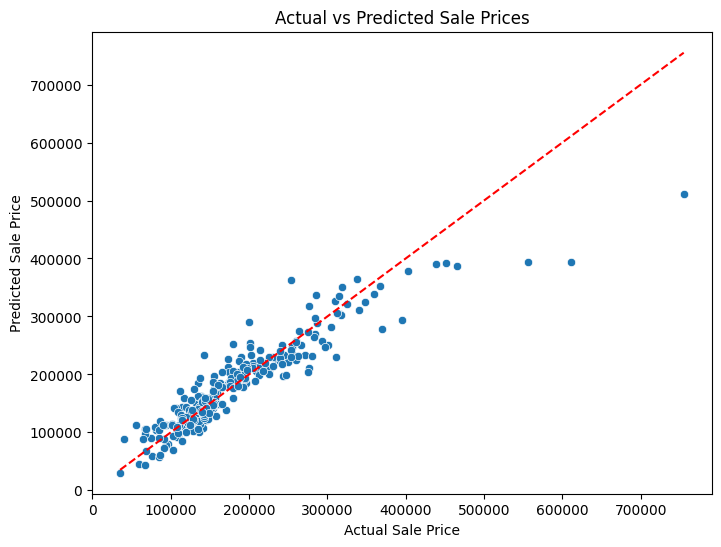

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    ax=ax
)

ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red"
)

ax.set_title("Actual vs Predicted Sale Prices")
ax.set_xlabel("Actual Sale Price")
ax.set_ylabel("Predicted Sale Price")

plt.show()

### Observation

- The predicted sale prices generally follow the actual sale prices, showing that the model has learned a meaningful relationship between the selected features and SalePrice.
- Most observations are reasonably close to the ideal prediction line, while some houses show larger differences between actual and predicted prices.
- The larger deviations may be associated with unusual or expensive properties that are more difficult for a simple Linear Regression model to predict accurately.

## 15. Checking Linear Regression Assumptions

After evaluating the model, we need to check whether the important assumptions of Linear Regression are reasonably satisfied.

We will examine linearity, normality of residuals, constant variance, independence of residuals and multicollinearity between the predictor variables.

### 15.1 Calculate Residuals

Residuals represent the difference between the actual SalePrice and the SalePrice predicted by the model.

A positive residual means the model underpredicted the house price, while a negative residual means the model overpredicted the house price.

In [51]:
residuals = y_test - y_pred

residuals.head()

892     12981.000861
1105     3174.839664
413      6132.968552
522    -11177.325146
1036    10603.315170
Name: SalePrice, dtype: float64

#### Observation

- The residuals represent the prediction errors made by the Linear Regression model.

- Both positive and negative residuals are present, meaning the model underpredicts some house prices and overpredicts others.

- These residuals will be used to check whether the assumptions of Linear Regression are reasonably satisfied.

### 15.2 Residuals vs Predicted Values

A residual plot helps us examine how the prediction errors are distributed across different predicted house prices.

Ideally, the residuals should be randomly scattered around zero without showing a clear pattern.

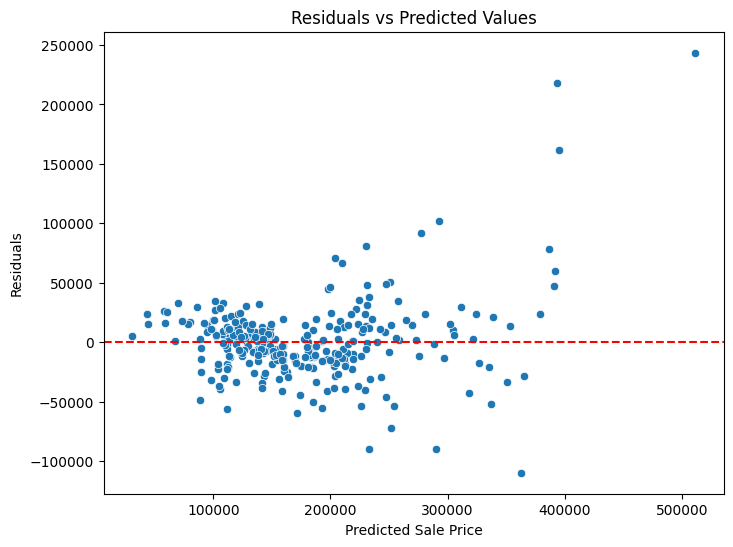

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    ax=ax
)

ax.axhline(
    y=0,
    linestyle="--",
    color="red"
)

ax.set_title("Residuals vs Predicted Values")
ax.set_xlabel("Predicted Sale Price")
ax.set_ylabel("Residuals")

plt.show()

#### Observation

- The residuals are distributed above and below the zero line.

- Most residuals are concentrated around the common range of predicted house prices, while some larger errors can be observed for certain houses.

- This plot will help us examine the linearity and constant variance assumptions of the model.

### 15.3 Check Linearity

Linear Regression assumes that the relationship between the predictor variables and SalePrice can be reasonably represented by a linear model.

We examine the residuals vs predicted values plot to check this assumption. If the residuals are randomly scattered around zero without a clear curved or systematic pattern, the linearity assumption is reasonably satisfied.

#### Observation

- The residual plot does not show a strong systematic curved pattern across most predicted values.

- The residuals are generally distributed around the zero line, suggesting that the linear model captures a meaningful part of the relationship between the selected features and SalePrice.

- Some larger deviations are present, especially for certain higher-priced houses, so the linearity assumption may not be perfectly satisfied.

### 15.4 Check Constant Variance

Linear Regression assumes that the residuals have approximately constant variance across different predicted values. This assumption is known as homoscedasticity.

If the spread of residuals remains roughly similar across the predicted values, the assumption is reasonably satisfied. If the spread increases or decreases noticeably, it may indicate heteroscedasticity.

#### Observation

- The spread of residuals is relatively smaller for houses in the common price range.

- Some larger residuals appear as the predicted house prices increase.

- This may indicate that the model has more difficulty maintaining consistent prediction errors for expensive houses.

- Therefore, the constant variance assumption should be interpreted with some caution.

### 15.5 Residual Distribution

The distribution of residuals helps us understand the overall shape of the model's prediction errors.

For a Linear Regression model, we expect most residuals to be concentrated around zero with an approximately normal distribution.

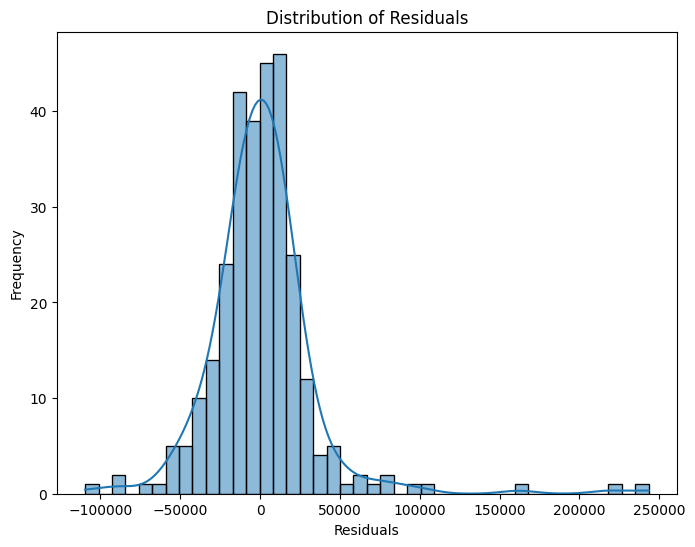

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    x=residuals,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Residuals")
ax.set_xlabel("Residuals")
ax.set_ylabel("Frequency")

plt.show()

#### Observation

- Most residuals are concentrated around zero, indicating that many predictions are relatively close to the actual SalePrice.

- The distribution allows us to identify whether the prediction errors are approximately symmetric or whether skewness and extreme residuals are present.

- A few large residuals may indicate houses for which the model made considerably larger prediction errors.

### 15.6 Q-Q Plot

A Q-Q plot compares the distribution of our residuals with a theoretical normal distribution.

If the residuals are normally distributed, most points should lie close to the straight reference line. Large deviations from the line indicate departures from normality.

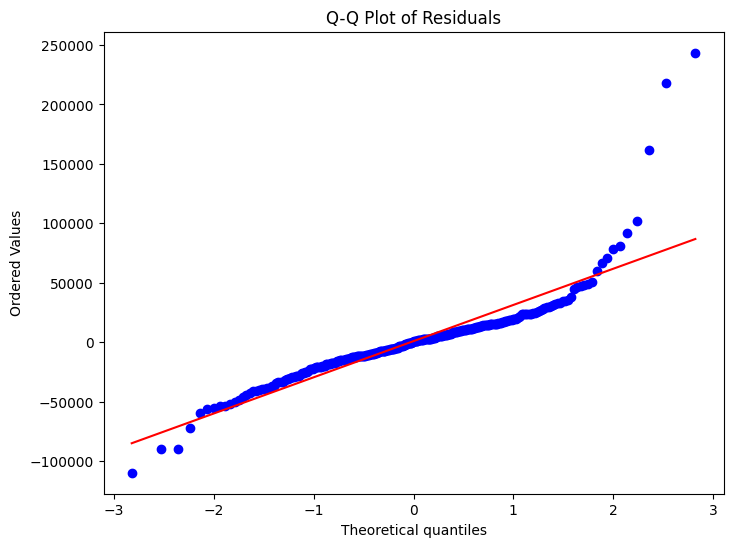

In [54]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=ax
)

ax.set_title("Q-Q Plot of Residuals")

plt.show()

#### Observation

- The Q-Q plot shows how closely the residuals follow a theoretical normal distribution.

- Points close to the reference line indicate residuals that behave approximately normally.

- Deviations from the line, especially near the ends, indicate the presence of extreme residuals or departures from normality.

### 15.7 Check Normality

The normality assumption states that the model's residuals should approximately follow a normal distribution.

We examine both the residual histogram and the Q-Q plot to evaluate this assumption. The histogram shows the overall shape of the residual distribution, while the Q-Q plot makes deviations from normality easier to identify.

#### Observation

- Most residuals are concentrated around zero.

- The histogram and Q-Q plot provide evidence about whether the residuals approximately follow a normal distribution.

- Any noticeable skewness or deviations from the Q-Q reference line at the extreme ends suggest that normality may not be perfectly satisfied.

- These deviations may be influenced by unusual houses or large prediction errors.

### 15.8 Durbin-Watson Test

The Durbin-Watson test is used to detect autocorrelation among the residuals.

The statistic ranges approximately from 0 to 4. A value close to 2 generally indicates little evidence of autocorrelation.

In [55]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)

print("Durbin-Watson Statistic:", round(dw, 4))

Durbin-Watson Statistic: 2.0517


#### Observation

- The Durbin-Watson statistic is close to 2.

- This suggests that there is no strong evidence of autocorrelation among the residuals.

- Therefore, the residual errors appear to be reasonably independent of each other.

### 15.9 Check Independence

Linear Regression assumes that the residual errors are independent of each other.

We use the Durbin-Watson statistic to check for autocorrelation among the residuals. A value close to 2 generally supports the independence assumption.

#### Observation

- The Durbin-Watson result indicates little evidence of autocorrelation among the residuals.

- Since the observations represent different houses rather than sequential time-series observations, strong dependence between residuals is not expected.

- The independence assumption appears to be reasonably satisfied.

### 15.10 Variance Inflation Factor

Variance Inflation Factor is used to detect multicollinearity among the predictor variables.

A high VIF indicates that a predictor may contain strongly overlapping information with other predictors in the model.

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X_train.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif_data.sort_values(
    by="VIF",
    ascending=False
).head(15)

,Feature,VIF
5,YearBuilt,12933.228524
6,YearRemodAdd,12804.976455
0,OverallQual,76.257759
36,ExterQual_TA,35.423623
1,GrLivArea,26.308272
4,FullBath,22.313430
37,CentralAir_Y,19.255791
33,KitchenQual_TA,18.907456
35,ExterQual_Gd,15.462242
18,Neighborhood_NAmes,14.966984


#### Observation

- VIF values show the level of multicollinearity present among the predictor variables.

- Features with low VIF values have relatively little linear dependence on the other predictors.

- Features with higher VIF values may contain overlapping information with other variables and should be examined more carefully.

- High VIF does not always mean that a feature should be removed immediately. The importance of the feature and its relationship with other predictors should also be considered.

### 15.11 Check Multicollinearity

Multicollinearity occurs when predictor variables are strongly related to each other.

Severe multicollinearity can make Linear Regression coefficients unstable and make it difficult to understand the individual effect of each predictor.

We use VIF values to identify possible multicollinearity among the features.

#### Observation

- Most features with lower VIF values do not show serious multicollinearity.

- Features with relatively high VIF values may share similar information with other predictors.

- These features should be examined before deciding whether any predictor needs to be removed.

- The use of drop_first=True during one-hot encoding also helps avoid perfect multicollinearity among categorical dummy variables.

### 15.12 Final Assumption Summary

After evaluating the major assumptions of Linear Regression, we can summarize how well the model satisfies the conditions required for reliable interpretation and prediction.

#### Observation

- Linearity was examined using the residuals vs predicted values plot. The model captures a meaningful linear relationship, although some larger prediction errors may still be present.

- Constant variance was also examined using the residual plot. Any increase in the spread of residuals for higher predicted prices may indicate some heteroscedasticity.

- Normality was examined using the residual histogram and Q-Q plot. Most residuals should remain around zero, while deviations at the extreme ends may indicate non-normal behavior or outliers.

- Independence was examined using the Durbin-Watson statistic. A value close to 2 suggests little evidence of autocorrelation among the residuals.

- Multicollinearity was examined using VIF. Features with high VIF values should be investigated for overlapping information before deciding whether they need to be removed.

- Overall, the Linear Regression model provides a strong baseline for predicting house prices, with an R² score of 0.851 and an Adjusted R² score of 0.8286. However, the assumption checks should be considered together with the model's larger errors for some expensive houses.

## 16. Final Model Training

After evaluating the Linear Regression model on unseen validation data, we can train the final model using all available training data.

Using the complete training dataset allows the model to learn from all available houses before making predictions on the Kaggle test dataset.

In [57]:
final_model = LinearRegression()

final_model.fit(X, y)

LinearRegression()

### Observation

- The final Linear Regression model was trained using all available observations from the training dataset.

- Unlike the earlier model, which was trained using only the training split, the final model uses the complete prepared dataset to learn from as much labeled data as possible.

- The earlier train-test split was used for model evaluation, while this final model will be used to predict SalePrice for the houses in the Kaggle test dataset.

- The final model should not be evaluated again using the previous X_test and y_test because those observations are now included in its training data.

## 17. Prepare Kaggle Test Data

The Kaggle test dataset contains house information but does not include SalePrice.

Before making predictions, we need to prepare the test data in exactly the same way as the training data. We will select the same features, apply the same categorical encoding and ensure that the final columns match the features used to train our Linear Regression model.

### 17.1 Save Id

The Id column uniquely identifies each house in the Kaggle test dataset.

Although Id is not used as a feature for predicting SalePrice, we need to save it because Kaggle requires both Id and the predicted SalePrice in the final submission file.

In [58]:
test_ids = test["Id"].copy()

test_ids.head()

0    1461
1    1462
2    1463
3    1464
4    1465
Name: Id, dtype: int64

#### Observation

- The Id values from the Kaggle test dataset have been stored separately.

- Id is not used as an input feature because it only identifies each house and does not describe any property characteristic.

- These IDs will be added back when creating the final Kaggle submission file.

### 17.2 Select the Same Features

The final model was trained using a specific set of selected features.

Therefore, we need to select the same original features from the Kaggle test dataset before applying preprocessing and making predictions.

In [59]:
test_data = test[selected_features].copy()

test_data.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,Neighborhood,KitchenQual,ExterQual,CentralAir
0,5,896,1.0,882.0,1,1961,1961,NAmes,TA,TA,Y
1,6,1329,1.0,1329.0,1,1958,1958,NAmes,Gd,TA,Y
2,5,1629,2.0,928.0,2,1997,1998,Gilbert,TA,TA,Y
3,6,1604,2.0,926.0,2,1998,1998,Gilbert,Gd,TA,Y
4,8,1280,2.0,1280.0,2,1992,1992,StoneBr,Gd,Gd,Y


#### Observation

- The same 11 original features used during model development have been selected from the Kaggle test dataset.

- This ensures that the test data contains the same types of house characteristics that were used to train the Linear Regression model.

- A separate copy was created so that further preprocessing does not modify the original test dataset.

### 17.3 Check Missing Values

The Kaggle test dataset contains different houses from the training dataset.

Even though our selected features did not contain missing values in the training data, the same features may contain missing values in the test data. Therefore, we need to check them before making predictions.

In [60]:
test_data.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      1
TotalBsmtSF     1
FullBath        0
YearBuilt       0
YearRemodAdd    0
Neighborhood    0
KitchenQual     1
ExterQual       0
CentralAir      0
dtype: int64

#### Observation

- The selected test features were checked separately for missing values because the Kaggle test dataset contains different observations from the training dataset.

- Any features with missing values must be handled before making predictions because Linear Regression cannot directly process missing values.

### 17.4 Handle Missing Values

Any missing values found in the Kaggle test data need to be handled before prediction.

For numerical features, we use the median calculated from the training dataset. For categorical features, we use the most frequent category from the training dataset.

Using values from the training data keeps the preprocessing process consistent and avoids learning preprocessing information from the test data.

In [61]:
for column in numerical_selected:
    if test_data[column].isnull().sum() > 0:
        test_data[column] = test_data[column].fillna(train[column].median())

for column in categorical_selected:
    if test_data[column].isnull().sum() > 0:
        test_data[column] = test_data[column].fillna(train[column].mode()[0])

In [62]:
test_data.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
YearRemodAdd    0
Neighborhood    0
KitchenQual     0
ExterQual       0
CentralAir      0
dtype: int64

In [63]:
test_data.isnull().sum().sum()

np.int64(0)

#### Observation

- Missing values in the selected test features were handled using information calculated from the training dataset.

- Numerical missing values were filled using the corresponding training median, while categorical missing values were filled using the corresponding training mode.

- After preprocessing, no missing values remain in the selected test features.

- Using training-based replacement values keeps the preprocessing of unseen test data consistent with the information available during model development.

### 17.5 Encode Categorical Features

The selected test data still contains categorical features such as Neighborhood, KitchenQual, ExterQual and CentralAir.

Since Linear Regression requires numerical input, these categorical features need to be converted into numerical dummy variables using the same one-hot encoding approach used for the training data.

In [64]:
test_data = pd.get_dummies(
    test_data,
    columns=categorical_selected,
    drop_first=True,
    dtype=int
)

test_data.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,CentralAir_Y
0,5,896,1.0,882.0,1,1961,1961,0,0,0,...,0,0,0,0,0,1,0,0,1,1
1,6,1329,1.0,1329.0,1,1958,1958,0,0,0,...,0,0,0,0,1,0,0,0,1,1
2,5,1629,2.0,928.0,2,1997,1998,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,6,1604,2.0,926.0,2,1998,1998,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,8,1280,2.0,1280.0,2,1992,1992,0,0,0,...,1,0,0,0,1,0,0,1,0,1


#### Observation

- The categorical features in the test dataset have been converted into numerical dummy variables.

- One category from each categorical feature was dropped to avoid redundant dummy variables.

- The test dataset now contains numerical features that can be provided to the Linear Regression model.

- However, we still need to ensure that its columns exactly match the columns used during model training.

### 17.6 Align Test Columns with Training Features

After one-hot encoding, the training and test datasets may not automatically contain exactly the same dummy columns.

The final model expects the same feature names and column order that were present in X during training. Therefore, we align the test data with X before making predictions.

In [65]:
test_data = test_data.reindex(
    columns=X.columns,
    fill_value=0
)

#### Observation

- The encoded test dataset was aligned with the feature columns used to train the final model.

- Any training feature that was missing from the test data after one-hot encoding was added and filled with zero.

- The column order was also adjusted to match X exactly.

- This ensures that each test feature is provided to the model in the same position and format used during training.

### 17.7 Verify Training and Test Features

Before making predictions, we need to verify that the prepared test dataset has exactly the same feature columns as X.

The number of rows can be different because the training and test datasets contain different houses, but the number, names and order of feature columns must match.

In [66]:
print("Training features shape:", X.shape)
print("Test features shape:", test_data.shape)

Training features shape: (1460, 38)
Test features shape: (1459, 38)


In [67]:
X.shape[1] == test_data.shape[1]

True

In [68]:
X.columns.equals(test_data.columns)

True

#### Observation

- The training and test datasets contain the same number of predictor columns after preprocessing.

- The column comparison returned True, confirming that the feature names and their order are identical.

- The number of rows is different because the training and Kaggle test datasets contain different houses.

- The prepared test data now has exactly the same feature structure expected by the final Linear Regression model.

### 17.8 Ready for Final Prediction

The Kaggle test dataset has now been fully prepared for the final Linear Regression model.

The house IDs have been saved, the same original features were selected, missing values were handled, categorical features were encoded and the final feature columns were aligned with the training data.

The processed test dataset is now ready to be used for predicting SalePrice.

In [69]:
test_data.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,CentralAir_Y
0,5,896,1.0,882.0,1,1961,1961,0,0,0,...,0,0,0,0,0,1,0,0,1,1
1,6,1329,1.0,1329.0,1,1958,1958,0,0,0,...,0,0,0,0,1,0,0,0,1,1
2,5,1629,2.0,928.0,2,1997,1998,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,6,1604,2.0,926.0,2,1998,1998,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,8,1280,2.0,1280.0,2,1992,1992,0,0,0,...,1,0,0,0,1,0,0,1,0,1


In [70]:
print("Missing values:", test_data.isnull().sum().sum())
print("Columns match:",X.columns.equals(test_data.columns))

Missing values: 0
Columns match: True


#### Observation

- The final test dataset contains no missing values.

- All categorical features have been converted into numerical form.

- The test feature columns exactly match the features used to train the final model.

- The Kaggle test dataset is now ready for final SalePrice prediction.

## 18 Predict SalePrice on Kaggle Test Data

### 18.1 Make Final Predictions

The Kaggle test dataset has been preprocessed and now contains the same features used to train our final Linear Regression model.

We can now use the final model to predict SalePrice for each house in the test dataset.

In [71]:
final_predictions = final_model.predict(test_data)

final_predictions[:10]

array([110322.50226539, 153832.0213147 , 170638.36171916, 186273.54226626,
       251616.8645483 , 178995.16013911, 168057.24994074, 172391.81262519,
       190273.85418631, 113184.75163334])

#### Observation

- The final Linear Regression model was used to predict SalePrice for every house in the Kaggle test dataset.

- Each row in test_data produces one predicted SalePrice.

- These predictions represent the model's estimated sale prices based on the selected house characteristics.

- The predicted values will now be combined with the corresponding house IDs to create the Kaggle submission file.

### 18.2 Check Number of Predictions

Before creating the submission file, we need to verify that the number of predicted SalePrice values matches the number of houses in the Kaggle test dataset.

In [72]:
print("Number of test houses:", len(test_data))
print("Number of predictions:", len(final_predictions))

Number of test houses: 1459
Number of predictions: 1459


#### Observation

- The number of predictions matches the number of houses in the Kaggle test dataset.

- This confirms that the model generated exactly one SalePrice prediction for each test observation.

- The predictions can now be matched with their corresponding house IDs.

### 18.3 Create Submission DataFrame

Kaggle requires the final predictions in a specific format containing the house Id and its predicted SalePrice.

We will combine the previously saved test IDs with the predicted SalePrice values to create the submission DataFrame.

In [73]:
submission = sample_submission.copy()

submission["SalePrice"] = final_predictions

submission.head()

,Id,SalePrice
0,1461,110322.502265
1,1462,153832.021315
2,1463,170638.361719
3,1464,186273.542266
4,1465,251616.864548


#### Observation

- A submission DataFrame has been created containing the Id of each test house and its predicted SalePrice.

- Each predicted SalePrice is matched with the corresponding house Id.

- The structure now follows the format required for the Kaggle House Prices submission.

### 18.4 Check Submission

Before saving the submission file, we should verify its shape, column names and missing values to ensure that the file is correctly structured.

In [74]:
print("Submission shape:", submission.shape)
print("\nMissing values:")
print(submission.isnull().sum())

submission.head()

Submission shape: (1459, 2)

Missing values:
Id           0
SalePrice    0
dtype: int64


,Id,SalePrice
0,1461,110322.502265
1,1462,153832.021315
2,1463,170638.361719
3,1464,186273.542266
4,1465,251616.864548


#### Observation

- The submission contains 1459 rows, representing all houses in the Kaggle test dataset.

- The submission contains the required Id and SalePrice columns.

- No missing values are present in the final submission.

- The submission is correctly structured and ready to be saved as a CSV file.

### 18.5 Save Submission File

The final submission DataFrame needs to be saved as a CSV file so that it can be submitted to Kaggle for evaluation.

In [75]:
submission.to_csv(
    "submission.csv",
    index=False
)

#### Observation

- The final predictions have been saved in submission.csv.

- The DataFrame index was excluded so that the file contains only the required Id and SalePrice columns.

- The submission file is now ready to be uploaded to Kaggle for evaluation.

## 19. Final Project Summary and Conclusion

In this project, we built an end-to-end Linear Regression model to predict house sale prices using the Ames Housing dataset.

We started by exploring the dataset and understanding the numerical and categorical features. Missing values, target distribution, correlations, feature relationships and outliers were analyzed before selecting the features for the model.

The selected data was preprocessed by handling missing values and encoding categorical variables. The dataset was then divided into training and testing sets to train and evaluate the Linear Regression model.

The model achieved an R² score of 0.851 and an Adjusted R² score of 0.8286, showing that the selected features explain a large portion of the variation in house prices. The MAE and RMSE were also examined to understand the size of the prediction errors.

Linear Regression assumptions were checked using residual analysis, the residual distribution, Q-Q plot, Durbin-Watson statistic and VIF.

After evaluating the model, a final Linear Regression model was trained using all available training data. The Kaggle test dataset was prepared using the same features and preprocessing structure, and final SalePrice predictions were generated.

Finally, the predictions were saved in submission.csv in the format required by Kaggle.

### Final Conclusion

#### Observation

- OverallQual, GrLivArea and other selected property characteristics showed strong relationships with SalePrice.

- The Linear Regression model achieved an R² score of 0.851, indicating that approximately 85.1% of the variation in SalePrice was explained by the model on the validation data.

- The Adjusted R² score of 0.8286 remained relatively close to the R² score after accounting for the number of predictors.

- The model performed reasonably well for most houses, although larger prediction errors were observed for some expensive and unusual properties.

- Residual analysis helped identify limitations in the linear model and showed that some assumptions may not be perfectly satisfied.

- Linear Regression provides a strong and interpretable baseline model for this house price prediction problem.

- Further improvements could include better feature engineering, log transformation of SalePrice, regularization techniques such as Ridge and Lasso Regression, and comparison with more advanced regression models.